Student Name : Loyana Parajuli

Student Number : 2414972

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

In [4]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/AI/Data/collab/week5/FruitinAmazon.zip"
extract_path = "dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed successfully")

Extraction completed successfully


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Identifying dataset classes

In [5]:
train_dir = "dataset/FruitinAmazon/train"

#getting the class name/subdirectories
class_names = sorted(os.listdir(train_dir))

print("Dataset name: ",os.listdir("dataset"))

if not class_names:
  print("No class directories foiunf in the train folder!!")
else:
  print("Class names:",class_names)



Dataset name:  ['FruitinAmazon']
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


# Visualizing sample images

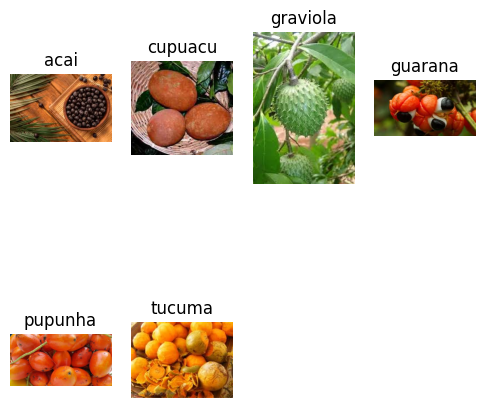

In [6]:
import random
import matplotlib.pyplot as plt
from PIL import Image

classes = sorted(os.listdir(train_dir))

plt.figure(figsize=(6,6))
#this is to display one random image from each class
for i, cls in enumerate(classes):
    class_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(2, (len(classes)//2)+1, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

The dataset contains images grouped into class folders. Each folder represents a fruit category. The images vary in orientation, lighting, and background but share common visual features that help the CNN learn patterns.

In [7]:
from PIL import Image,UnidentifiedImageError

corrupted_images = [] #list to store all the corrupted images
#looping through each class folder and cheking for the corrupted images
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir,class_name)
    if os.path.isdir(class_path):  #ensuring it is a valid directory
      images = os.listdir(class_path)
      for file in os.listdir(class_path):
        image_path = os.path.join(class_path,file)
        try:
            with Image.open(image_path) as img:
              img.verify() #verifying if image can be opened correctly

        except (IOError, UnidentifiedImageError):

                corrupted_images.append(image_path)
                os.remove(image_path)
                print(f"Removed corrupted image: {image_path}")

if corrupted_images:
    print("Corrupted images found:")
    for img in corrupted_images:
        print(img)
else:
  print("No corrupted images found.")

No corrupted images found.


# Checking class imbalance

In [8]:
#dictionary to store the number of images in each class
class_counts = {}

for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path):
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png','.jpg','jpeg'))]
    class_counts[class_name] = len(images) #counts images in each class

#printing class imbalance
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid image count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("="* 45)


Class Distribution:
Class Name               Valid image count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


# Random Image Selection

In [9]:
import random
selected_images = [] # Store image paths
selected_labels = [] # Store corresponding class names
for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path):
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if images: # Ensure the class folder is not empty
      selected_img = os.path.join(class_path, random.choice(images))
      selected_images.append(selected_img)
      selected_labels.append(class_name)

# Random image Plot


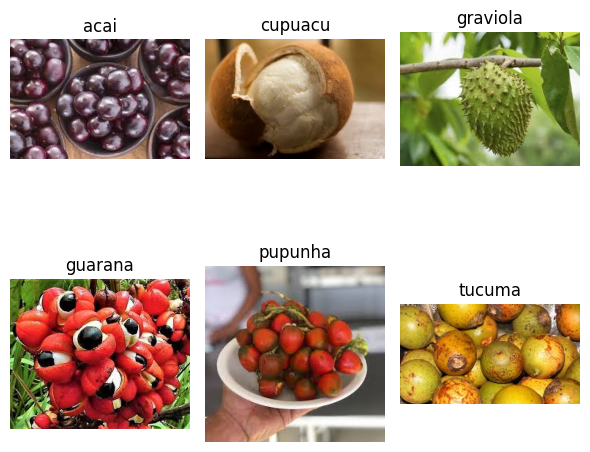

In [10]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
# Determine grid size
num_classes = len(selected_images)
cols = (num_classes + 1) // 2 # Determine columns
rows = 2 # Fixed rows for layout
fig, axes = plt.subplots(rows, cols, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
  if i < num_classes:
    img = mpimg.imread(selected_images[i])
    ax.imshow(img)
    ax.set_title(selected_labels[i])
    ax.axis("off")
  else:
    ax.axis("off") # Hide empty subplots
plt.tight_layout()
plt.show()

# Data loading and preprocessing

In [11]:
import tensorflow as tf

img_height = 224
img_width = 224
batch_size = 32
validation_split = 0.2
#normalizing pixel values from 0-255 to 0-1
rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height,img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)
#loading validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height,img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)
#applying normalization to datasets
train_ds = train_ds.map(lambda x,y:(rescale(x),y))
val_ds = val_ds.map(lambda x,y:(rescale(x),y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


# Data Augmentation

In [22]:
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import tensorflow as tf

data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
]

@tf.keras.utils.register_keras_serializable()
def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

# CNN model Task 1

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import Dropout, Dense, Flatten
from tensorflow.keras import layers

model = Sequential([

    # Data augmentation
    layers.Lambda(data_augmentation, input_shape=(224,224,3)),

    # Block 1
    Conv2D(32, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 4
    Conv2D(256, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Flatten
    Flatten(),

    # Fully connected layer
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    # Output layer
    Dense(len(class_names), activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [24]:
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 6,814,278 (25.99 MB)

 Trainable params: 6,813,062 (25.99 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [25]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [26]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Save the best model during training
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Stop training if validation loss does not improve
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.1991 - loss: 2.8892
Epoch 1: val_loss improved from None to 1.70763, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 24s 6s/step - accuracy: 0.2222 - loss: 2.6749 - val_accuracy: 0.0000e+00 - val_loss: 1.7076
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4890 - loss: 1.6389
Epoch 2: val_loss did not improve from 1.70763
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 5s/step - accuracy: 0.5139 - loss: 1.5977 - val_accuracy: 0.1111 - val_loss: 1.7395
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5955 - loss: 1.1404
Epoch 3: val_loss did not improve from 1.70763
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 6s/step - accuracy: 0.5833 - loss: 1.0721 - val_accuracy: 0.0000e+00 - val_loss: 3.0082
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6898 - loss: 0.9387
Epoch 4: val_loss did not improve from 1.70763
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.694

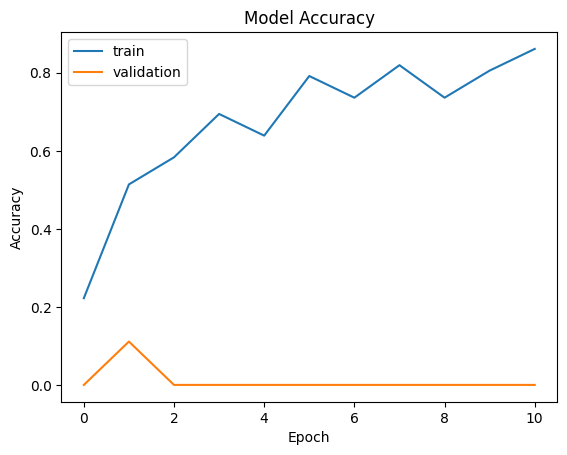

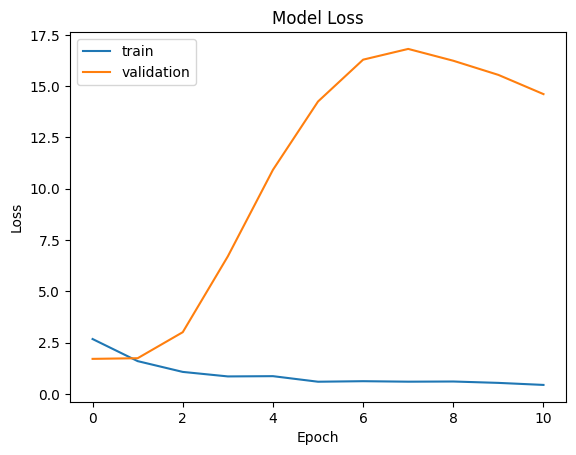

In [27]:
plt.plot(history.history['accuracy'],label='train')
plt.plot(history.history['val_accuracy'],label='validation')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='validation')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [28]:
test_loss,test_acc = model.evaluate(val_ds)

print("Test Accuracy:",test_acc)
print("Test Loss:",test_loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 754ms/step - accuracy: 0.0000e+00 - loss: 1.7076
Test Accuracy: 0.0
Test Loss: 1.7076294422149658


In [29]:
# Save the trained model
model.save("fruit_cnn_model.keras")

# Load the saved model
from tensorflow.keras.models import load_model
loaded_model = load_model("fruit_cnn_model.keras")

# Evaluate the loaded model
loss, accuracy = loaded_model.evaluate(val_ds)

print("Loaded Model Accuracy:", accuracy)
print("Loaded Model Loss:", loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0000e+00 - loss: 1.7076
Loaded Model Accuracy: 0.0
Loaded Model Loss: 1.7076294422149658


In [30]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images,labels in val_ds:

    predictions = loaded_model.predict(images)

    pred_labels = np.argmax(predictions,axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(pred_labels)
unique_labels = np.unique(y_true)

print(classification_report(y_true,y_pred, labels=unique_labels,target_names=[classes[i] for i in unique_labels]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 893ms/step
              precision    recall  f1-score   support

     pupunha       0.00      0.00      0.00       3.0
      tucuma       0.00      0.00      0.00      15.0

   micro avg       0.00      0.00      0.00      18.0
   macro avg       0.00      0.00      0.00      18.0
weighted avg       0.00      0.00      0.00      18.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

# Transfer Learning (VGG16)

In [31]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Load Pretrained VGG16 Model

In [32]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Freeze pretrained layers

In [33]:
for layer in base_model.layers:
    layer.trainable = False

# Build Transfer Learning Model

In [34]:
model_transfer = Sequential([

    base_model,

    Flatten(),

    Dense(256, activation='relu'),

    Dense(len(class_names), activation='softmax')
])

# Compile the Model

In [35]:
model_transfer.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the Model

In [36]:
history_transfer = model_transfer.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 58s 18s/step - accuracy: 0.1250 - loss: 5.7234 - val_accuracy: 0.6111 - val_loss: 1.0378
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 55s 18s/step - accuracy: 0.3889 - loss: 8.8077 - val_accuracy: 0.4444 - val_loss: 1.6046
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 58s 18s/step - accuracy: 0.5556 - loss: 2.4562 - val_accuracy: 0.3333 - val_loss: 2.0733
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 55s 18s/step - accuracy: 0.8333 - loss: 0.3886 - val_accuracy: 0.7222 - val_loss: 0.8320
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 57s 19s/step - accuracy: 0.8611 - loss: 0.4355 - val_accuracy: 0.8889 - val_loss: 0.5118
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 56s 18s/step - accuracy: 0.9028 - loss: 0.2920 - val_accuracy: 0.9444 - val_loss: 0.4901
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 56s 18s/step - accuracy: 0.9861 - loss: 0.1030 - val_accuracy: 0.8889 - val_loss: 0.2831
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 57s 18s/step - accuracy: 0.9861 - loss: 0.0368 - val_accuracy: 0.7778 - val_loss: 0.8029


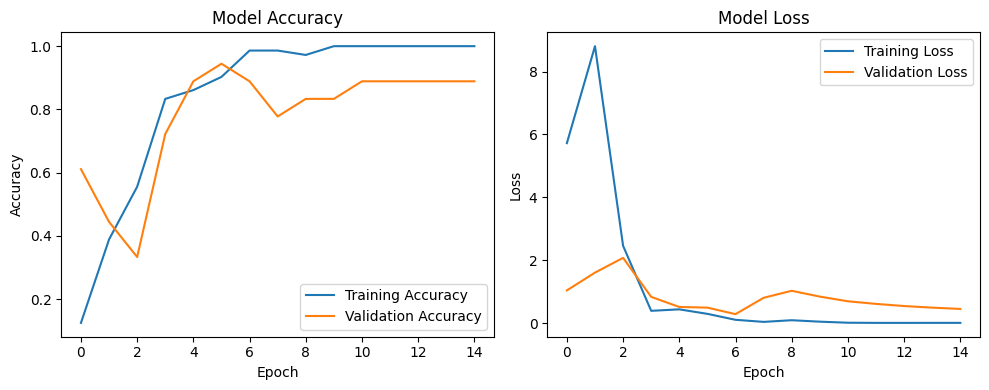

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# Accuracy graph
plt.subplot(1,2,1)
plt.plot(history_transfer.history['accuracy'], label='Training Accuracy')
plt.plot(history_transfer.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss graph
plt.subplot(1,2,2)
plt.plot(history_transfer.history['loss'], label='Training Loss')
plt.plot(history_transfer.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate the Model

In [38]:
loss, accuracy = model_transfer.evaluate(val_ds)

print("Transfer Learning Accuracy:", accuracy)
print("Transfer Learning Loss:", loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 0.8889 - loss: 0.4489
Transfer Learning Accuracy: 0.8888888955116272
Transfer Learning Loss: 0.4488890469074249


# Fine-Tuning

In [39]:
base_model.trainable = True

for layer in base_model.layers[:-4]:
    layer.trainable = False

# Recompile with smaller learning rate

In [40]:
from tensorflow.keras.optimizers import RMSprop

model_transfer.compile(
    optimizer=RMSprop(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Fine-Tuned Model

In [41]:
history_finetune = model_transfer.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 57s 18s/step - accuracy: 1.0000 - loss: 0.0040 - val_accuracy: 0.8889 - val_loss: 0.4422
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 58s 19s/step - accuracy: 1.0000 - loss: 0.0032 - val_accuracy: 0.8889 - val_loss: 0.4379
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 55s 18s/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 0.8889 - val_loss: 0.4363
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 56s 18s/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 0.8889 - val_loss: 0.4340
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 57s 18s/step - accuracy: 1.0000 - loss: 0.0022 - val_accuracy: 0.8889 - val_loss: 0.4327
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 55s 18s/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.8889 - val_loss: 0.4328
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 66s 23s/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.8889 - val_loss: 0.4302
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 66s 23s/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.8889 - val_loss: 0.4265


# Final Evaluation

In [42]:
loss, accuracy = model_transfer.evaluate(val_ds)

print("Fine-Tuned Model Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.8889 - loss: 0.4225
Fine-Tuned Model Accuracy: 0.8888888955116272
